In [15]:
import star, wind, cme
from default_vals import bands
from astropy import units as un, constants as const
import matplotlib.pyplot as plt
import numpy as np

In [9]:
distance = 3.2 * un.pc
physical_size = 5*un.au
n_pix = 121
c, b = bands['H'].values()
h_band = [c - b/2, c + b/2]


/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 0.98, 'Photon flux from star')

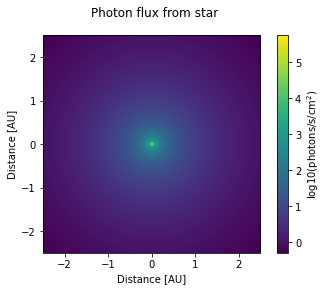

In [13]:
s = star.Star(temp=5080, radius=0.72*un.R_sun, distance=3.2*un.pc, linear_extent=physical_size, dim=n_pix, wavelength_range=h_band)
s.make_stellar_grids()
fig, ax = s.plot_stellar_flux()
fig.suptitle("Photon flux from star at the earth")

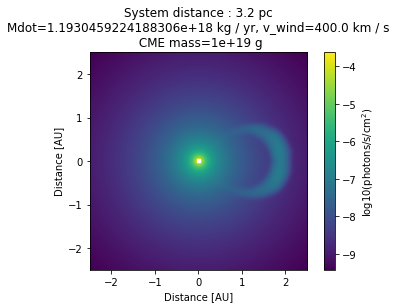

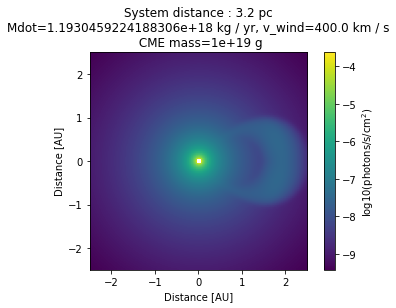

In [22]:
s.make_wind(Mdot=30*2e-14*const.M_sun/un.yr) # instantiates wind
s.make_cme(mass=1e19*un.g, horizontal_height_factor=2.3, dR_factor=0.2, smear=True, smear_sig=n_pix/90) #instantiates CME
s.particle_to_photon_flux()
fig, ax = s.plot_particle_fluxes()

s.make_cme(mass=1e19*un.g, horizontal_height_factor=0.1, dR_factor=0.5, smear=True, smear_sig=n_pix/90) #instantiates CME
s.particle_to_photon_flux()
fig, ax = s.plot_particle_fluxes()